## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix
)

import xgboost as xgb
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

## **Preprocessing** 

In [2]:
df = pd.read_csv("../data/dataset-uci.csv")
# Modalitas A: Sinyal Fisik Tubuh (Bioimpedans) — non-invasif
fitur_fisik = [
    "Body Mass Index (BMI)",
    "Total Body Water (TBW)",
    "Extracellular Water (ECW)",
    "Intracellular Water (ICW)",
    "Extracellular Fluid/Total Body Water (ECF/TBW)",
    "Total Body Fat Ratio (TBFR) (%)",
    "Lean Mass (LM) (%)",
    "Body Protein Content (Protein) (%)",
    "Visceral Fat Rating (VFR)",
    "Bone Mass (BM)",
    "Muscle Mass (MM)",
    "Obesity (%)",
    "Total Fat Content (TFC)",
    "Visceral Fat Area (VFA)",
    "Visceral Muscle Area (VMA) (Kg)"
]

# Modalitas B: Sinyal Kimia Tubuh (Lab Darah) — invasif
fitur_kimia = [
    "Glucose",
    "Total Cholesterol (TC)",
    "Low Density Lipoprotein (LDL)",
    "High Density Lipoprotein (HDL)",
    "Triglyceride",
    "Aspartat Aminotransferaz (AST)",
    "Alanin Aminotransferaz (ALT)",
    "Alkaline Phosphatase (ALP)",
    "Creatinine",
    "Glomerular Filtration Rate (GFR)",
    "C-Reactive Protein (CRP)",
    "Hemoglobin (HGB)",
    "Vitamin D"
]

# Modalitas C: Kontrol Baseline (Demografis)
fitur_demografi = [
    "Age", "Gender", "Comorbidity",
    "Coronary Artery Disease (CAD)",
    "Hypothyroidism", "Hyperlipidemia",
    "Diabetes Mellitus (DM)"
]

fitur_keseluruhan = fitur_demografi + fitur_fisik + fitur_kimia
X = df[fitur_keseluruhan]
y = df["Gallstone Status"]

print(f"Total fitur  : {X.shape[1]}")
print(f"Total sampel : {X.shape[0]}")
print(f"Distribusi label:\n{y.value_counts()}")

Total fitur  : 35
Total sampel : 319
Distribusi label:
Gallstone Status
0    161
1    158
Name: count, dtype: int64


## **Split Dataset**

In [3]:
# Train-test split (stratified, 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (255, 35)
Test  : (64, 35)


## **Standardisasi Fitur Data untuk Mencegah `data leakage`**

In [4]:
# Standard Scaling (fit hanya pada train → transform pada test)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)



## **Pemisahan Fitur Berdasarkan Modalitas Data Klinis.**

In [5]:
# ── TRAIN ──────────────────────────────────────────────────────────────────
X_train_fisik     = X_train_scaled[fitur_fisik]        # Modalitas A
X_train_kimia     = X_train_scaled[fitur_kimia]        # Modalitas B
X_train_demografi = X_train_scaled[fitur_demografi]    # Modalitas C

# ── TEST ───────────────────────────────────────────────────────────────────
X_test_fisik     = X_test_scaled[fitur_fisik]
X_test_kimia     = X_test_scaled[fitur_kimia]
X_test_demografi = X_test_scaled[fitur_demografi]

print("Pemisahan modalitas selesai!")
print(f"  Modalitas A (Fisik)    : {X_train_fisik.shape[1]} fitur")
print(f"  Modalitas B (Kimia)    : {X_train_kimia.shape[1]} fitur")
print(f"  Modalitas C (Demografi): {X_train_demografi.shape[1]} fitur")

Pemisahan modalitas selesai!
  Modalitas A (Fisik)    : 15 fitur
  Modalitas B (Kimia)    : 13 fitur
  Modalitas C (Demografi): 7 fitur


## **korelasi fitur modalitas fisik**

<Axes: >

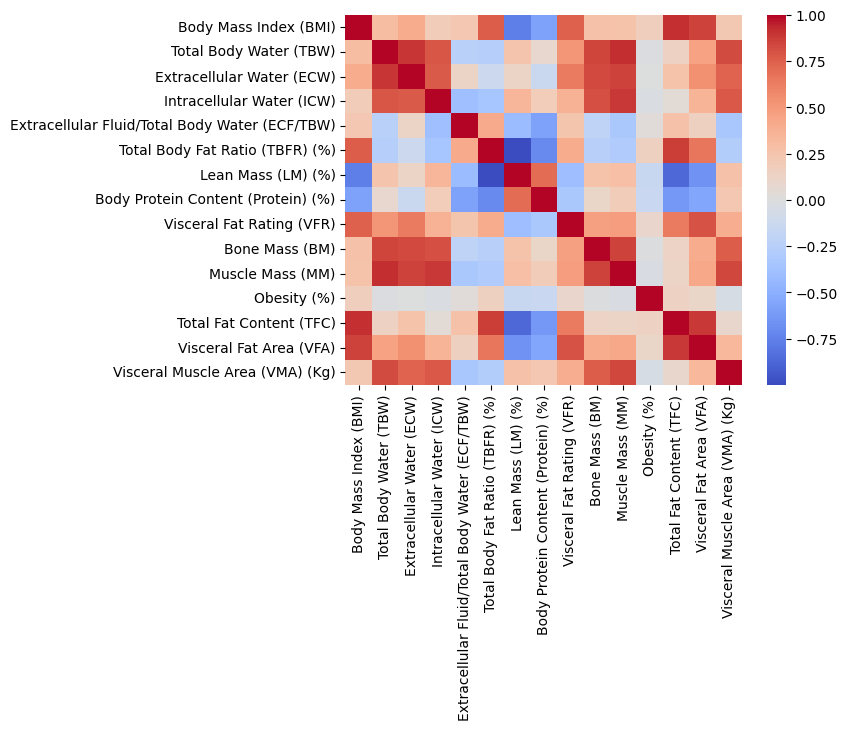

In [6]:
# Heatmap korelasi per modalitas
corr_fisik = X_train_fisik.corr()
sns.heatmap(corr_fisik, annot=False, cmap='coolwarm')

# **Tier 1 — Base Learners**

## **XGBoost (Modalitas Fisik)**

In [7]:
# Definisi model XGBoost untuk Modalitas A
model_fisik = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Stratified 5-Fold CV → menghasilkan meta-fitur P_fisik untuk train set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

P_fisik_train = cross_val_predict(
    model_fisik, X_train_fisik, y_train,
    cv=cv, method='predict_proba'
)[:, 1]   # Probabilitas kelas positif

# Fit ulang pada seluruh train set → untuk prediksi test set
model_fisik.fit(X_train_fisik, y_train)
P_fisik_test = model_fisik.predict_proba(X_test_fisik)[:, 1]

print(f"P_fisik_train  — mean: {P_fisik_train.mean():.4f}, std: {P_fisik_train.std():.4f}")
print(f"P_fisik_test   — mean: {P_fisik_test.mean():.4f}, std: {P_fisik_test.std():.4f}")

P_fisik_train  — mean: 0.4790, std: 0.3196
P_fisik_test   — mean: 0.5096, std: 0.2988


## **LightGBM (Modalitas Kimia)**

In [8]:
# Definisi model LightGBM untuk Modalitas B
model_kimia = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

# Stratified 5-Fold CV → meta-fitur P_kimia untuk train set
P_kimia_train = cross_val_predict(
    model_kimia, X_train_kimia, y_train,
    cv=cv, method='predict_proba'
)[:, 1]

# Fit ulang pada seluruh train set
model_kimia.fit(X_train_kimia, y_train)
P_kimia_test = model_kimia.predict_proba(X_test_kimia)[:, 1]

print(f"P_kimia_train  — mean: {P_kimia_train.mean():.4f}, std: {P_kimia_train.std():.4f}")
print(f"P_kimia_test   — mean: {P_kimia_test.mean():.4f}, std: {P_kimia_test.std():.4f}")

P_kimia_train  — mean: 0.4923, std: 0.3619
P_kimia_test   — mean: 0.4626, std: 0.3657


## **Eliminasi Multikolinieritas Fitur Berbasis Treshold Korelasi.**

In [9]:
def drop_high_corr(df, threshold=0.85):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train_fisik, dropped_fisik = drop_high_corr(X_train_fisik)
X_test_fisik = X_test_fisik.drop(columns=dropped_fisik)

# **Tier 2**

## **Pembentukan Matriks Tier 2 (Meta-Features)**

Matriks Tier 2 = `[P_fisik | P_kimia | Modalitas C (Demografis)]`

In [10]:
# ── Matriks Tier 2 untuk TRAINING ──────────────────────────────────────────
meta_train = pd.DataFrame({
    'P_fisik': P_fisik_train,
    'P_kimia': P_kimia_train
})

X_tier2_train = pd.concat(
    [meta_train, X_train_demografi.reset_index(drop=True)],
    axis=1
)

# Gabungkan dengan Modalitas C
X_tier2_train = pd.concat([meta_train, X_train_demografi.reset_index(drop=True)], axis=1)
X_tier2_train.index = X_train_demografi.index

# ── Matriks Tier 2 untuk TESTING ───────────────────────────────────────────
meta_test = pd.DataFrame({
    'P_fisik': P_fisik_test,
    'P_kimia': P_kimia_test
})

X_tier2_test = pd.concat(
    [meta_test, X_test_demografi.reset_index(drop=True)],
    axis=1
)

X_tier2_test = pd.concat([meta_test, X_test_demografi.reset_index(drop=True)], axis=1)
X_tier2_test.index = X_test_demografi.index

print("Matriks Tier 2 berhasil dibentuk!")
print(f"  Shape Train : {X_tier2_train.shape}")
print(f"  Shape Test  : {X_tier2_test.shape}")
print(f"\nKolom Tier 2 : {list(X_tier2_train.columns)}")
print("\nSampel 5 baris pertama (Train):")
X_tier2_train.head()

Matriks Tier 2 berhasil dibentuk!
  Shape Train : (255, 9)
  Shape Test  : (64, 9)

Kolom Tier 2 : ['P_fisik', 'P_kimia', 'Age', 'Gender', 'Comorbidity', 'Coronary Artery Disease (CAD)', 'Hypothyroidism', 'Hyperlipidemia', 'Diabetes Mellitus (DM)']

Sampel 5 baris pertama (Train):


,P_fisik,P_kimia,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM)
241,0.979248,0.993319,0.957108,1.003929,-0.668013,-0.179969,-0.191273,-0.15523,-0.398862
66,0.758583,0.310020,-1.146880,-0.996086,1.312723,-0.179969,-0.191273,-0.15523,-0.398862
230,0.417204,0.313208,0.228805,-0.996086,1.312723,-0.179969,-0.191273,-0.15523,2.507133
42,0.224595,0.432994,0.228805,-0.996086,-0.668013,-0.179969,-0.191273,-0.15523,-0.398862
280,0.864599,0.989263,0.390650,1.003929,1.312723,-0.179969,-0.191273,-0.15523,2.507133


## **Train *meta-learner* dan Inferensi Probabilitas pada Matriks Tier 2.**

In [11]:
# Meta-Classifier: Logistic Regression
meta_learner = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

meta_learner.fit(X_tier2_train, y_train)

# Prediksi pada test set
y_pred       = meta_learner.predict(X_tier2_test)
y_pred_proba = meta_learner.predict_proba(X_tier2_test)[:, 1]

print("Meta-Learner selesai dilatih!")

Meta-Learner selesai dilatih!


# **Evaluasi Model**

## **Metrik Performance Model *stacking ensemble* multi-modal.**

In [12]:
acc   = accuracy_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_pred_proba)
f1    = f1_score(y_test, y_pred, average='weighted')

print("=" * 45)
print("  EVALUASI MULTI-MODAL FUSION STACKING")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred))

  EVALUASI MULTI-MODAL FUSION STACKING
  Accuracy  : 0.8281
  ROC-AUC   : 0.8975
  F1-Score  : 0.8281

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        32
           1       0.84      0.81      0.83        32

    accuracy                           0.83        64
   macro avg       0.83      0.83      0.83        64
weighted avg       0.83      0.83      0.83        64



## **Confussion Matrix Model**

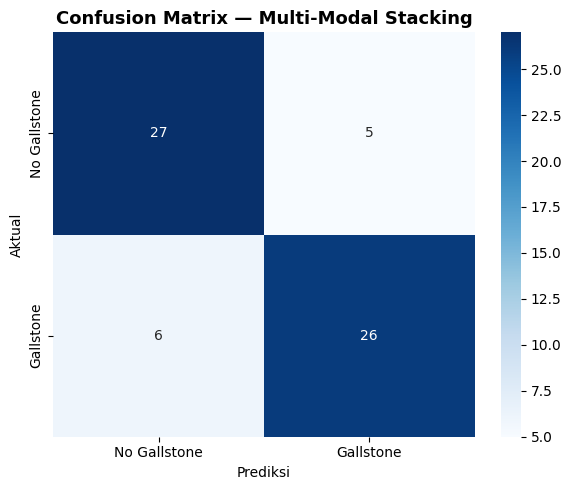

In [13]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Gallstone', 'Gallstone'],
    yticklabels=['No Gallstone', 'Gallstone'],
    ax=ax
)
ax.set_title('Confusion Matrix — Multi-Modal Stacking', fontsize=13, fontweight='bold')
ax.set_ylabel('Aktual')
ax.set_xlabel('Prediksi')

plt.tight_layout()
plt.savefig('../result/Confusion Matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Separabilitas Ruang Keputusan meta-fitur Berbasis *scatter plot*.**

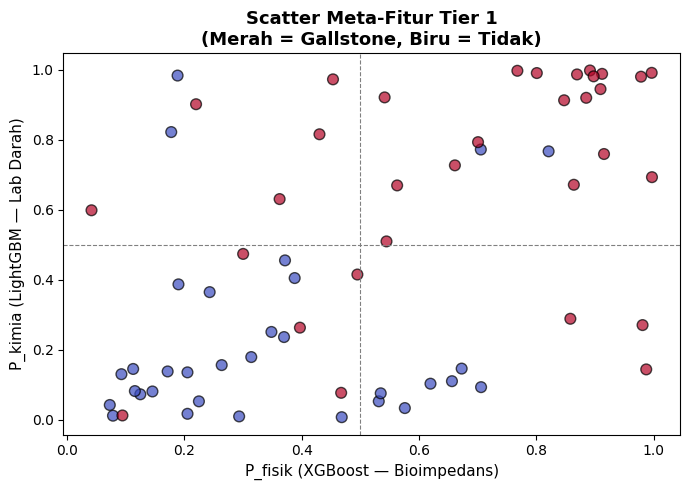

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    P_fisik_test, P_kimia_test,
    c=y_test.values, cmap='coolwarm',
    edgecolors='k', alpha=0.7, s=60
)
ax.set_xlabel('P_fisik (XGBoost — Bioimpedans)', fontsize=11)
ax.set_ylabel('P_kimia (LightGBM — Lab Darah)', fontsize=11)
ax.set_title('Scatter Meta-Fitur Tier 1\n(Merah = Gallstone, Biru = Tidak)', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../result/Scatter Plot.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis Kontribusi Fitur Terhadap Prediksi Risiko Berbasis Koefisien *meta-learner*.**

Koefisien Logistic Regression pada Tier 2 menunjukkan seberapa besar kontribusi masing-masing sinyal (fisik vs kimia vs demografis) terhadap keputusan akhir.

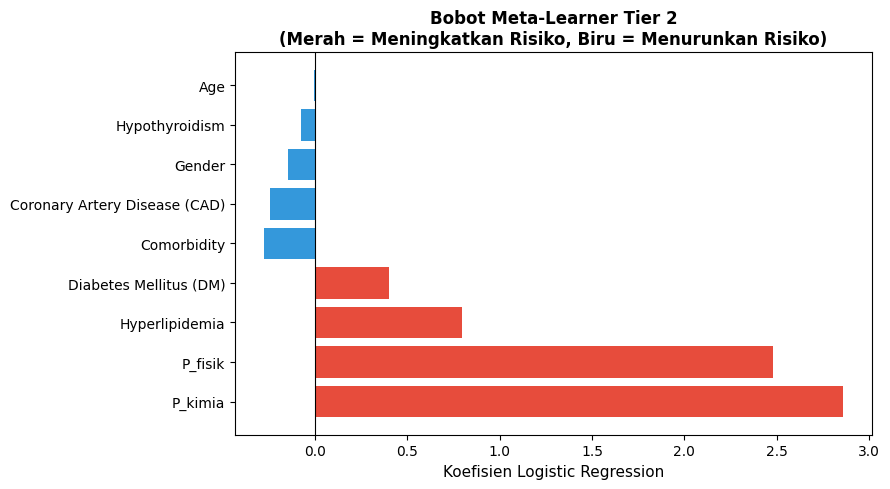

                        Fitur  Koefisien
                      P_kimia   2.857854
                      P_fisik   2.479949
               Hyperlipidemia   0.797338
       Diabetes Mellitus (DM)   0.404345
                  Comorbidity  -0.273421
Coronary Artery Disease (CAD)  -0.239869
                       Gender  -0.142893
               Hypothyroidism  -0.074815
                          Age  -0.002950


In [15]:
coef_df = pd.DataFrame({
    'Fitur'     : X_tier2_train.columns,
    'Koefisien' : meta_learner.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in coef_df['Koefisien']]
ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koefisien Logistic Regression', fontsize=11)
ax.set_title('Bobot Meta-Learner Tier 2\n(Merah = Meningkatkan Risiko, Biru = Menurunkan Risiko)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../result/meta_learner_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print(coef_df.to_string(index=False))